## 1. FourCastNet v2 與 LLAT 2-way colab 教學版

## 在colab中模擬虛擬環境 (請使用google中的colab)

### download couple_FCNV2_LLAT model, FCNv2 weight and LLAT weight

*  step0: 連到自己的google雲端(方便拿取輸出結果)
*  step1: git clone couple_FCNV2_LLAT
*  step2: 下載FCNV2 weight
*  step3: gdown下載LLAT weight

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
## Step1: download couple_FCNV2_LLAT from github
!git clone https://github.com/yungyun0721/couple_FCNV2_LLAT

## Step2: download FCNV2 weight
%cd /content/couple_FCNV2_LLAT/global_model/FCNV2
!wget 'https://api.ngc.nvidia.com/v2/models/nvidia/modulus/modulus_fcnv2_sm/versions/v0.2/files/fcnv2_sm.zip'
!unzip fcnv2_sm.zip
!mv fcnv2_sm weight
!rm -rf fcnv2_sm.zip

## Step3: download LLAT weight
!sudo pip install gdown
%cd /content/couple_FCNV2_LLAT/regional_model/DLAMPty

!gdown --id 153kZPubjRA2KSE_bPrdpe2uSRXqP675H --output onnx/v57_5d.onnx

Mounted at /content/drive
Cloning into 'couple_FCNV2_LLAT'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 111 (delta 23), reused 104 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 7.02 MiB | 6.00 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/couple_FCNV2_LLAT/global_model/FCNV2
--2026-05-05 10:17:47--  https://api.ngc.nvidia.com/v2/models/nvidia/modulus/modulus_fcnv2_sm/versions/v0.2/files/fcnv2_sm.zip
Resolving api.ngc.nvidia.com (api.ngc.nvidia.com)... 184.33.2.6, 52.36.127.163
Connecting to api.ngc.nvidia.com (api.ngc.nvidia.com)|184.33.2.6|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://xfiles.ngc.nvidia.com/org/nvidia/team/modulus/models/modulus_fcnv2_sm/versions/v0.2/files/fcnv2_sm.zip?ssec-algo=AES256&versionId=5EOzwamxNkLnRC.WfT.7pANCO1lZKGuV&ssec-key=Co7fmfofTkol8OmYOgvAcqgNqPzwUDdr22iJPpgPOQJHYsM

### 建置FCNV2需要的環境
*  Step1: 下載各種packages (colab 沒有的環境)

In [ ]:
# install the environment
!pip install -q -U xarray zarr gcsfs fsspec dask
!pip install -q metpy pysolar cartopy
!pip install -q torch_harmonics
!pip install -q ruamel.yaml
!pip install -q netcdf4 cfgrib pygrib
!pip install -q onnxruntime # if cpu
!pip install -U onnx onnxruntime-gpu # if gpu
!pip install -q xarray_regrid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.8/318.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 1.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 28.8 MB/s eta 0:00:00
   ━━

### 下載initial 資料

In [ ]:
# download the initial condition ERA5 (2026042700)
%cd /content/couple_FCNV2_LLAT
!python download_ERA5_from_google_for_model_input.py --scheduled-time 2024102600 --tc-center 16.3	137.1 --save-folder input_data

/content/couple_FCNV2_LLAT
finish FCNV2 IC:2024102500
finish LLAT IC:2024102500
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 666, in _exitfunc
    f()
  File "/usr/lib/python3.12/weakref.py", line 590, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gcsfs/core.py", line 406, in close_session
    asyn.sync(asyn.loop[0], session.close, timeout=0.1)
  File "/usr/local/lib/python3.12/dist-packages/fsspec/asyn.py", line 103, in sync
    raise return_result
  File "/usr/local/lib/python3.12/dist-packages/fsspec/asyn.py", line 56, in _runner
    result[0] = await coro
                ^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/tasks.py", line 520, in wait_for
    return await fut
           ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/aiohttp/client.py", line 1360, in close
    await self._connector.close()
  File "/usr

### FCNV2資料展示 (可以跳過)

/content/couple_FCNV2_LLAT


Text(0, 0.5, 'Latitude')

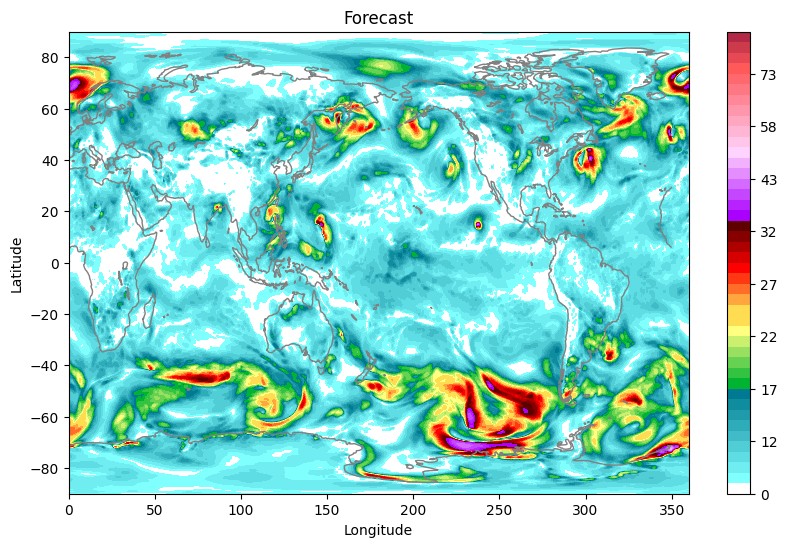

In [ ]:
%cd /content/couple_FCNV2_LLAT
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

IC_data = np.load('/content/couple_FCNV2_LLAT/input_data/FCNV2_2024102600_input.npy')
IC_flip = np.flip(IC_data, axis=1)
# variables order (73 variables)
ordering = [ "10u",  "10v", "100u", "100v",  "2t",  "sp",  "msl", "tcwv",
        "u50",  "u100", "u150", "u200", "u250", "u300", "u400", "u500", "u600", "u700", "u850", "u925", "u1000",
        "v50",  "v100", "v150", "v200", "v250", "v300", "v400", "v500", "v600", "v700", "v850", "v925", "v1000",
        "z50",  "z100", "z150", "z200", "z250", "z300", "z400", "z500", "z600", "z700", "z850", "z925", "z1000",
        "t50",  "t100", "t150", "t200", "t250", "t300", "t400", "t500", "t600", "t700", "t850", "t925", "t1000",
        "r50",  "r100", "r150", "r200", "r250", "r300", "r400", "r500", "r600", "r700", "r850", "r925", "r1000"]
index_ordering = 18
# index_ordering = 15
wsp_lev = [0,4,6,8,10,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,34,36,38,40,43,46,49,52,55,58,61,64,67,70,73,76,79,82,85]
wsp_color = ['#ffffff','#80ffff','#6fedf1','#5fdde4','#50cdd5','#40bbc7','#2facba','#1f9bac','#108c9f','#007a92',\
            '#00b432','#33c341','#67d251','#99e060','#cbf06f','#ffff80','#ffdd52','#ffdc52','#ffa63e','#ff6d29','#ff3713','#ff0000','#d70000','#af0000','#870000','#5f0000',\
            '#aa00ff','#b722fe','#c446ff','#d46aff','#e38dff','#f1b1ff','#ffd3ff',\
            '#ffc6ea','#ffb6d5','#ffa6c1','#ff97ac','#ff8798','#fe7884','#ff696e','#ff595a','#e74954','#cc3a4c','#b22846','#9a1941']

coast = pd.read_csv('/content/couple_FCNV2_LLAT/plot_figure/coast.csv')
coast_lon = coast.lon_map.copy()
coast_lon[coast.lon_map<0]=coast.lon_map[coast.lon_map<0]+360
coast_lon[(coast.lon_map<0) & (coast.lon_map>=-10)]=np.nan
coast.lon_map = coast_lon
# lon lat 850 hpa windspeed
IC_for_plot = np.sqrt(IC_flip[index_ordering,:,:]**2+IC_flip[index_ordering+13,:,:]**2)
xx, yy = np.meshgrid(np.linspace(0,359.75,1440), np.linspace(-90, 90, 721))
plt.figure(figsize=(10,6))
plt.plot(coast.lon_map,coast.lat_map,color='gray',linewidth=1)
plt.contourf(xx, yy, IC_for_plot, levels=wsp_lev, colors=wsp_color)
# plt.contourf(xx, yy, IC_flip[57,:,:], cmap="rainbow", levels=np.linspace(210,315,43))
plt.title('Forecast')
plt.colorbar()
plt.xlabel('Longitude');plt.ylabel('Latitude')

### LLAT 資料展示 (可以跳過)

/content/couple_FCNV2_LLAT/plot_figure


/usr/local/lib/python3.12/dist-packages/pysolar/numeric.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  dd = numpy.array(d, dtype='datetime64[D]')
/usr/local/lib/python3.12/dist-packages/pysolar/numeric.py:63: UserWarning: no explicit representation of timezones available for np.datetime64
  dy = numpy.array(d, dtype='datetime64[Y]')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


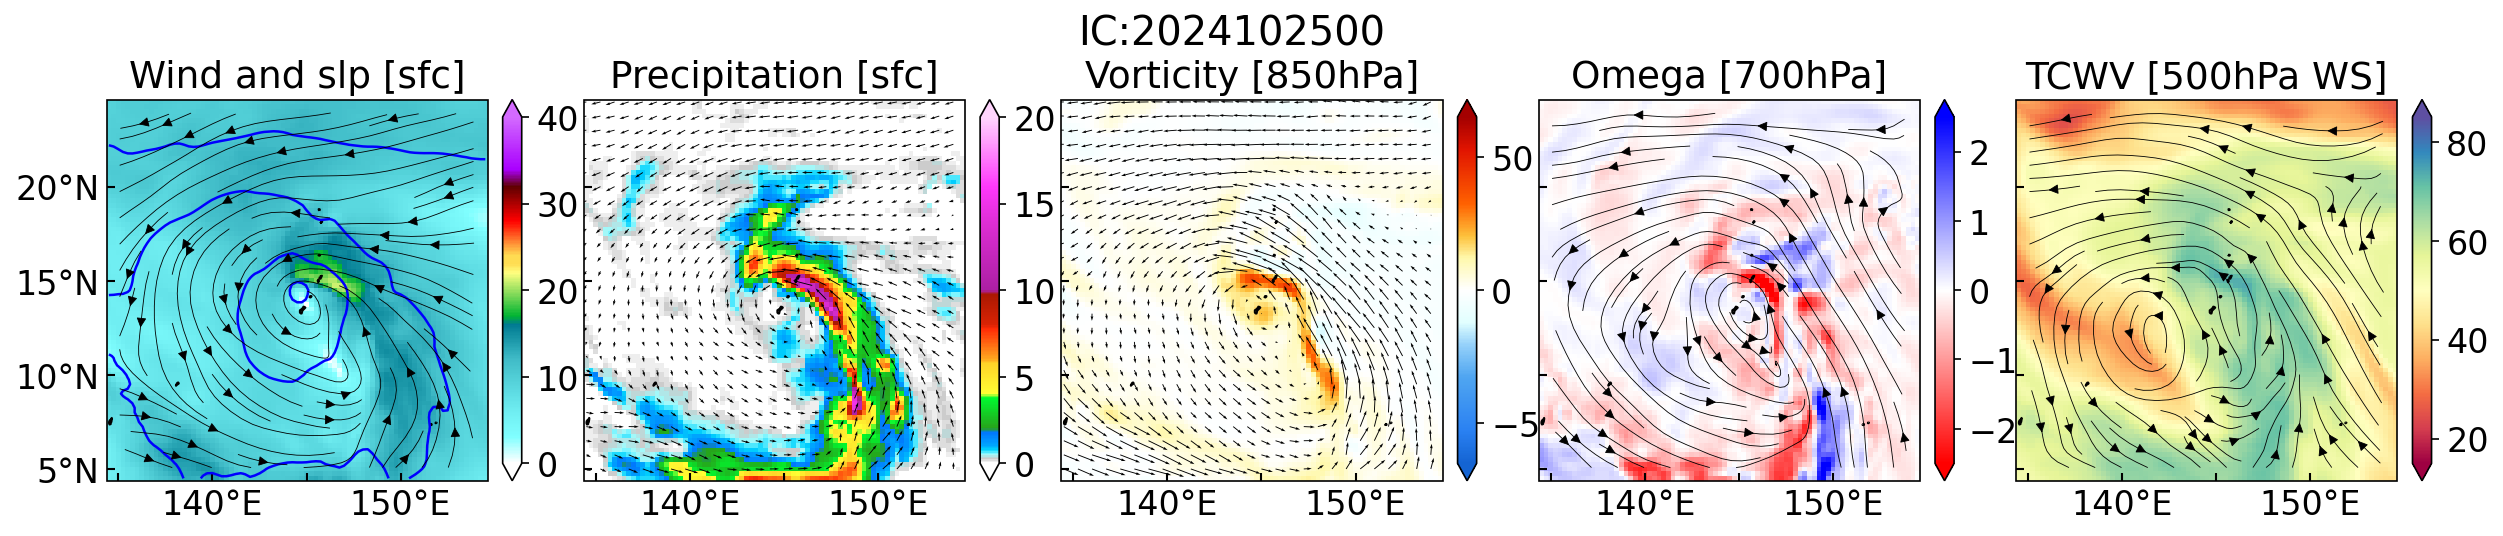

In [ ]:
%cd /content/couple_FCNV2_LLAT/plot_figure/
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os, datetime
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
import matplotlib.axes as maxes
from matplotlib import gridspec
import matplotlib.transforms as mtransforms
from matplotlib.ticker import FuncFormatter
from plot_figure_tools import make_cmap,calc_additional_vars, to_xarray, lat_formatter, lon_formatter


IC_time = '2024102600'
model_datetime = datetime.datetime.strptime(IC_time, "%Y%m%d%H")
IC_data = "/content/couple_FCNV2_LLAT/input_data/LLAT_2024102600_input.nc"
data_xr = xr.open_dataset(IC_data)
data_xr = calc_additional_vars(data_xr, True).squeeze("time", drop=True)

# setting for plot
info = {
        "model_title": "v57 5d (SG, ra)",
        "upper_vars": ['u', 'v', 't', 'q', 'z', 'w'],
        "upper_units": ["m/s", "m/s", "K", "kg kg**-1", "m**2 s**-2", "Pa s**-1"],
        "surface_vars": ['u10', 'v10', 't2m', 'd2m', 'msl', 'sp', 'tcwv', 'tp', 'mtnlwrf', 'sst_filled', 'f', 'solar', 'hgt', 'landmask', 'diurnal_sin', 'diurnal_cos', 'doy_sin', 'doy_cos'],
        "surface_units": ["m/s", "m/s", "K", "K", "Pa", "Pa", "kg m**-2", "m", 'W m**-2', 'K', '1/s', 'W m**-2', 'm', '1', '1', '1', '1', '1'],
        "pressure_levels" : [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000],
        'coastline_color': 'darkslategray',
    }

## for colorbar
quiver_skip = (slice(None, None, 3), slice(None, None, 3))
windspeed_cmap = make_cmap("clist_WS")
prec_cmap = make_cmap("clist_prec")
prec_levels = [0, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 17, 20]
prec_cticks = prec_levels[::2]
prec_cticks.pop(1)
vort_cmap = make_cmap("clist_vort")

fig = plt.figure(figsize=(20, 4), dpi=150, layout="tight")

font = {'size'       : 16
}
axes = {'titlesize'  : 16,
'labelsize'  : 16,
}
mpl.rc('font', **font)  # pass in the font dict as kwargs
mpl.rc('axes', **axes)

gs = gridspec.GridSpec(1, 5, wspace=0.15, hspace=0.15, top=0.88)
ax = None
position = 0
fig.suptitle(f'IC:{model_datetime.strftime("%Y%m%d%H")}', y=0.95)

################# model plot #################
X, Y = np.meshgrid(data_xr.longitude, data_xr.latitude)
###########  slp(msl)  ###########
ax = fig.add_subplot(gs[position],sharex=ax,sharey=ax, projection=ccrs.PlateCarree())

ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
ax.coastlines() # type: ignore
ax.set_title(f"Wind and slp [sfc]", fontsize=18)
a0 = ax.pcolormesh(
    data_xr.longitude, data_xr.latitude,
    np.squeeze(data_xr.ws10), cmap=windspeed_cmap, vmin=0, vmax=40
)
divider = make_axes_locatable(ax)

ax.contour(
    data_xr.longitude, data_xr.latitude,
    (np.squeeze(data_xr.msl) / 100), levels=np.arange(900, 1033, 4)
    , colors="b", linewidths=1.2
)
ax.streamplot(
    X, Y,
    data_xr.u10,
    data_xr.v10,
    color="k",
    linewidth=0.4,
)

ax.set_yticks(np.arange(5, 61, 5))
ax.tick_params(labelleft=True, direction='in')

ax.set_xticks(np.arange(90, 161, 5))
ax.tick_params(labelbottom=True, direction='in', width=1.0, length=4)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=maxes.Axes)
plt.colorbar(a0, cax=cax, extend="both")

###########  precp.(tp)  ###########
position += 1
ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
ax.coastlines() # type: ignore

ax.set_title(f"Precipitation [sfc]", fontsize=18)
a0 = ax.pcolormesh(
    data_xr.longitude, data_xr.latitude,
    np.squeeze(data_xr.tp)*1000, cmap=prec_cmap, vmin=0, vmax=20
)
divider = make_axes_locatable(ax)

ax.quiver(
    data_xr.longitude[quiver_skip[0]], data_xr.latitude[quiver_skip[1]],
    np.squeeze(data_xr.u10)[quiver_skip],
    np.squeeze(data_xr.v10)[quiver_skip],
    color="k",
    linewidth=0.4,
    scale=400
)

ax.set_yticks(np.arange(5, 61, 5))
ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)

ax.set_xticks(np.arange(90, 161, 5))
ax.tick_params(labelbottom=True, direction='in', width=1.0, length=4)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=maxes.Axes)
plt.colorbar(a0, cax=cax, extend="both")

###########  850hpa vorticity(vort)  ###########
position += 1
ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
ax.coastlines() # type: ignore

ax.set_title(f"Vorticity [850hPa]", fontsize=18)
a0 = ax.pcolormesh(
    data_xr.longitude, data_xr.latitude,
    (1e5*np.squeeze(data_xr.vort.sel(level=850))),
    cmap=vort_cmap, vmin=-65, vmax=65
)
divider = make_axes_locatable(ax)

ax.quiver(
    data_xr.longitude[quiver_skip[0]], data_xr.latitude[quiver_skip[1]],
    np.squeeze(data_xr.u.sel(level=850))[quiver_skip],
    np.squeeze(data_xr.v.sel(level=850))[quiver_skip],
    color="k",
    linewidth=0.4,
    scale=400
)

ax.set_yticks(np.arange(5, 61, 5))
ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)


ax.set_xticks(np.arange(90, 161, 5))
ax.tick_params(labelbottom=True, direction='in', width=1.0, length=4)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=maxes.Axes)
plt.colorbar(a0, cax=cax, extend="both")


###########  omega  ###########
position += 1

ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
ax.coastlines() # type: ignore

ax.set_title(f"Omega [700hPa]", fontsize=18)
a0 = ax.pcolormesh(
    data_xr.longitude, data_xr.latitude,
    np.squeeze(data_xr.w.sel(level=700)), cmap="bwr_r", vmin=-2.5, vmax=2.5
)
divider = make_axes_locatable(ax)
# if np.mod(position, fig_col)==0:
#     cax = divider.append_axes("right", size="5%", pad=0.2, axes_class=maxes.Axes)
#     plt.colorbar(a0, cax=cax, extend="both")

ax.streamplot(
    X, Y,
    data_xr.u.sel(level=700),
    data_xr.v.sel(level=700),
    color="k",
    linewidth=0.4,
)
# ax.set_title(f"{model_title} Wind and ω [700hPa]")

ax.set_yticks(np.arange(5, 61, 5))
ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)

ax.set_xticks(np.arange(90, 161, 5))
ax.tick_params(labelbottom=True, direction='in', width=1.0, length=4)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=maxes.Axes)
plt.colorbar(a0, cax=cax, extend="both")


###########  tcwv  ###########
position += 1

ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
ax.coastlines() # type: ignore

a0 = ax.pcolormesh(
    data_xr.longitude, data_xr.latitude,
    np.squeeze(data_xr.tcwv), cmap="Spectral", vmin=15, vmax=85
)

ax.set_title(f"TCWV [500hPa WS]", fontsize=18)
ax.streamplot(
    X, Y,
    data_xr.u.sel(level=500),
    data_xr.v.sel(level=500),
    color="k",
    linewidth=0.4,
)
ax.set_yticks(np.arange(5, 61, 5))
ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)

ax.set_xticks(np.arange(90, 161, 5))
xticks = ax.get_xticks()
ax.tick_params(labelbottom=True, direction='in', width=1.0, length=4)
ax.set_xticklabels([f"{abs(int(t))}°{'E' if t >= 0 else 'W'}" if i % 2 == 0 else "" for i, t in enumerate(xticks)])

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=maxes.Axes)
plt.colorbar(a0, cax=cax, extend="both")

plt.subplots_adjust(left=0.125,
        bottom=0.1,
        right=0.9,
        top=0.9,
        wspace=0.05,
        hspace=0.05)
plt.show()


### LLAT input data (nc => array)

In [ ]:
LLAT_info = {
        "model_title": "v57 5d (SG, ra)",
        "upper_vars": ['u', 'v', 't', 'q', 'z', 'w'],
        "upper_units": ["m/s", "m/s", "K", "kg kg**-1", "m**2 s**-2", "Pa s**-1"],
        "surface_vars": ['u10', 'v10', 't2m', 'd2m', 'msl', 'sp', 'tcwv', 'tp', 'mtnlwrf', 'sst_filled', 'f', 'solar', 'hgt', 'landmask', 'diurnal_sin', 'diurnal_cos', 'doy_sin', 'doy_cos'],
        "surface_units": ["m/s", "m/s", "K", "K", "Pa", "Pa", "kg m**-2", "m", 'W m**-2', 'K', '1/s', 'W m**-2', 'm', '1', '1', '1', '1', '1'],
        "pressure_levels" : [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000],
        'coastline_color': 'darkslategray',
    }

IC_time = '2024102600'
model_datetime = datetime.datetime.strptime(IC_time, "%Y%m%d%H")
IC_data_path = "/content/couple_FCNV2_LLAT/input_data/LLAT_2024102600_input.nc"
IC_dataset = xr.open_dataset(IC_data_path)
IC_dataset = calc_additional_vars(IC_dataset, True)
input_upper = np.stack([IC_dataset[var].values for var in LLAT_info['upper_vars']], axis=-1).squeeze()
input_surface = np.stack([IC_dataset[var].values for var in LLAT_info['surface_vars']], axis=-1).squeeze()
lon, lat = np.meshgrid(IC_dataset.longitude, IC_dataset.latitude)
input_surface = np.concatenate((input_surface, np.stack([lon, lat],axis=-1)), axis=-1)
print(input_upper.shape,input_surface.shape)

/usr/local/lib/python3.12/dist-packages/pysolar/numeric.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  dd = numpy.array(d, dtype='datetime64[D]')
/usr/local/lib/python3.12/dist-packages/pysolar/numeric.py:63: UserWarning: no explicit representation of timezones available for np.datetime64
  dy = numpy.array(d, dtype='datetime64[Y]')


(13, 81, 81, 6) (81, 81, 20)


## FCNV2-LLAT 預報
#### 目前使用GPU，預報120小時(每6小時一報)
### LLAT 每3小時一報

In [ ]:
# FCNV2 LLAT 2-way predicting
%cd /content/couple_FCNV2_LLAT
!python inference_2_way_test.py --FCNV2_IC_path input_data/FCNV2_2024102600_input.npy --LLAT_IC_path input_data/LLAT_2024102600_input.nc --IC_time 2024102600 --save_folder output_data_2_way --fore_hour 120 #--FCNV2_device cpu
!python inference_one_way_test.py --FCNV2_IC_path input_data/FCNV2_2024102600_input.npy --LLAT_IC_path input_data/LLAT_2024102600_input.nc --IC_time 2024102600 --save_folder output_data_one_way --fore_hour 120 #--FCNV2_device cpu


/content/couple_FCNV2_LLAT
initialize model ...
FCNV2 weight: global_model/FCNV2/weight, device: cuda
FCNV2 Model and weights are loaded.
LLAT.yaml: regional_model/DLAMPty/onnx/v57_5d.yaml, device: cpu
inference with ['CPUExecutionProvider']
Model and weights are loaded.
save folder: output_data_one_way
load IC data and save ...
FCNV2 IC path: input_data/FCNV2_2024102500_input.npy
LLAT IC path: input_data/LLAT_2024102500_input.nc
It needs to calc additional vars.
/usr/local/lib/python3.12/dist-packages/pysolar/numeric.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  dd = numpy.array(d, dtype='datetime64[D]')
/usr/local/lib/python3.12/dist-packages/pysolar/numeric.py:63: UserWarning: no explicit representation of timezones available for np.datetime64
  dy = numpy.array(d, dtype='datetime64[Y]')
/content/couple_FCNV2_LLAT/global_model/FCNV2/fourcastnetv2/layers.py:623: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `to

### 完成預報後
#### 尋找颱風中心位置

In [ ]:
# Finding the TC center
%cd /content/couple_FCNV2_LLAT/finding_TC_center
## 2-way
!python finding_FCNV2_TC_center.py --FCNV2_path ../output_data_2_way/FCNV2 --IC_for_TC_center 16.3 137.1 --IC_time 2024102600 --save_folder ../output_data_2_way
!python finding_LLAT_TC_center.py --LLAT_path ../output_data_2_way/LLAT --IC_time 2024102600 --save_folder ../output_data_2_way
## one-way
!python finding_FCNV2_TC_center.py --FCNV2_path ../output_data_one_way/FCNV2 --IC_for_TC_center 16.3 137.1 --IC_time 2024102600 --save_folder ../output_data_one_way
!python finding_LLAT_TC_center.py --LLAT_path ../output_data_one_way/LLAT --IC_time 2024102600 --save_folder ../output_data_one_way

/content/couple_FCNV2_LLAT/finding_TC_center
finish TC initial time = 2024102500
finish initial time = 2024102500


### 預報完成後，查看結果
#### 劃出路徑圖

/content/couple_FCNV2_LLAT/plot_figure


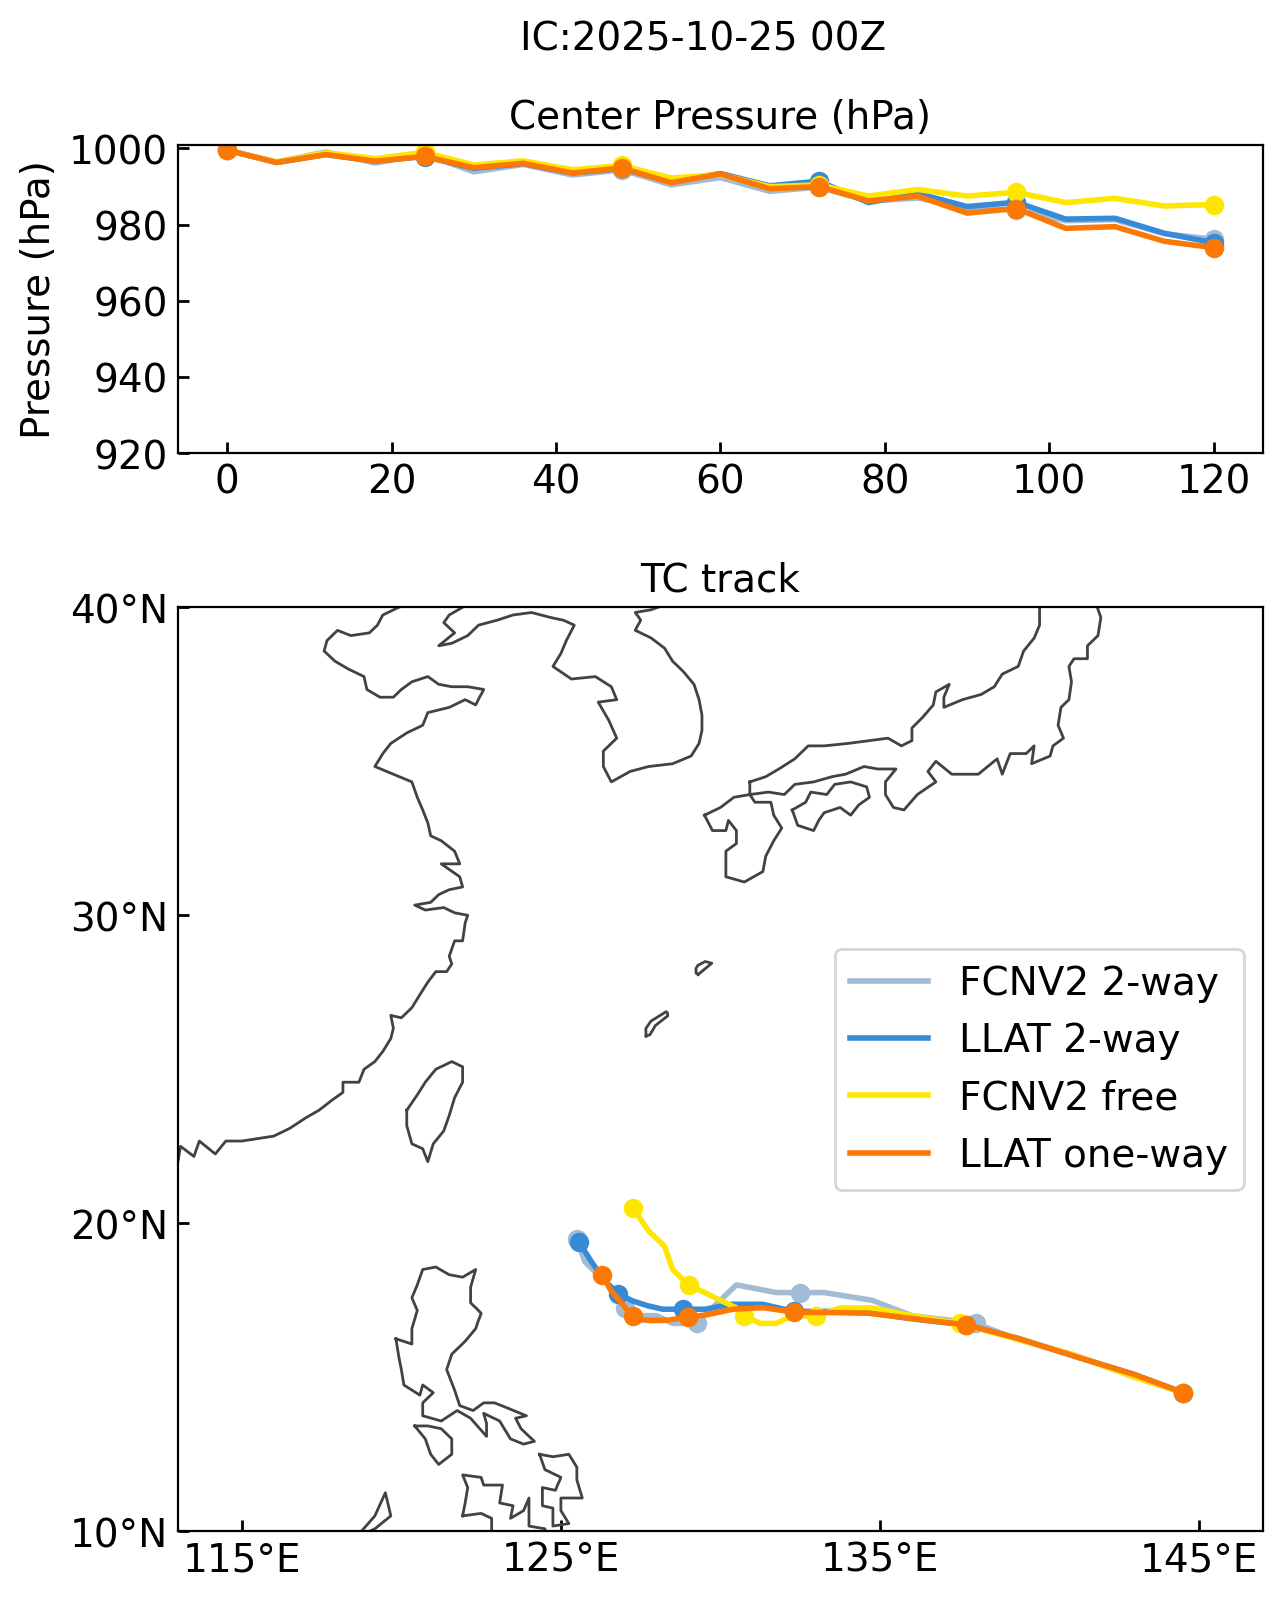

In [ ]:
%cd /content/couple_FCNV2_LLAT/plot_figure/
from matplotlib.ticker import FuncFormatter
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
from plot_figure_tools import lat_formatter, lon_formatter

initial_time = datetime.datetime.strptime("2025102600", "%Y%m%d%H")
exp_files = {
    "FCNV2 2-way": f"../output_data_2_way/FCNV2_TC_track_radius5.csv",
    "LLAT 2-way": f"../output_data_2_way/LLAT_TC_track_radius5.csv",
    "FCNV2 free": f"../output_data_one_way/FCNV2_TC_track_radius5.csv",
    "LLAT one-way": f"../output_data_one_way/LLAT_TC_track_radius5.csv",
    }

colors = {
    # "ERA5 bdy": '#FF5050',
    "LLAT ERA5": "#FE9292FF",
    "LLAT one-way": "#FC7805",
    "FCNV2 free": "#FFE600",
    "LLAT 2-way": "#398AD6",
    "FCNV2 2-way": "#A1BCD5",
}


# 建立畫布
fig = plt.figure(figsize=(7, 9),dpi=200)  # 可依比例調整大小

font = {'weight'     : 'normal',
        'size'       : 14
        }
axes = {'titlesize'  : 14,
        'titleweight': 'normal',
        'labelsize'  : 14,
        'labelweight': 'normal'
        }
mpl.rc('font', **font)  # pass in the font dict as kwargs
mpl.rc('axes', **axes)
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.25)  # 1:3 水平比例
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# 每條模型路徑畫一條線
for label, path in exp_files.items():
    exp_track = pd.read_csv(path)
    time = np.arange(len(exp_track))*6

    # 子圖 1（佔 1 單位寬度）
    ax1.plot(time, exp_track['Pressure (hPa)']/100, '-',color=colors[label], linewidth=2, label=label)
    ax1.plot(time[0::4], exp_track['Pressure (hPa)'].iloc[0::4]/100, 'o',color=colors[label], linewidth=2)


    # 子圖 2（佔 3 單位寬度）
    ax2.plot(exp_track['lon'], exp_track['lat'], '-',color=colors[label], linewidth=2, label=label)
    ax2.plot(exp_track['lon'].iloc[0::4], exp_track['lat'].iloc[0::4], 'o',color=colors[label], linewidth=2)

ax1.tick_params(direction='in', width=1, length=4)
ax2.tick_params(direction='in', width=1, length=4)

ax2.plot(coast.lon_map, coast.lat_map, color='#424242', linewidth=1.0)
ax2.set_xlim([113, 147])
ax2.set_ylim([10,40])
# ax2.set_xlim([123, 157])
# ax2.set_ylim([0,30])


ax1.set_title("Center Pressure (hPa)")
ax1.set_yticks(np.arange(920,1011,20))

ax1.set_ylabel("Pressure (hPa)")
ax1.tick_params(axis='x', labelsize=14)


ax2.set_title("TC track")

ax2.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
ax2.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
# ax2.set_xticks(np.arange(125,156,10))
# ax2.set_yticks(np.arange(0,31,10))
ax2.set_xticks(np.arange(115,146,10))
ax2.set_yticks(np.arange(10,41,10))

ax2.legend()
plt.suptitle(f'IC:{initial_time.strftime("%Y-%m-%d %H")}Z',y=0.95,fontsize=14)
plt.show()


#### Plan views

In [ ]:
import os
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes

import matplotlib.transforms as mtransforms
from matplotlib.ticker import FuncFormatter
from plot_figure_tools import make_cmap,calc_additional_vars, to_xarray

prec_levels = [0, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 17, 20]

start_time = '2024102600'
model_datetime = datetime.datetime.strptime(start_time, "%Y%m%d%H")
sample_for_FCNV2 = '../input_data/LLAT_2024102600_input.nc'
experiments_path = {
    # "ERA5": f"/wk2/yungyun/FCNV2_TC/{TC_ID}/ERA5/for_DLAMPty",
    "LLAT 2-way":f"../output_data_2_way/LLAT/",
    "FCNV2 free":f"../output_data_one_way/FCNV2/",
    # "FCNV2 2-way":f"../output_data_2_way/FCNV2/"
}
TC_track_FCNV2_path = {
    "FCNV2 free":f"../output_data_one_way/FCNV2_TC_track_radius5.csv",
    "FCNV2 2-way":f"../output_data_2_way/FCNV2_TC_track_radius5.csv"
}

save_plot = 'plan_views'
os.makedirs(save_plot, exist_ok=True)
# setting for plot
info = {
        "model_title": "v57 5d (SG, ra)",
        "upper_vars": ['u', 'v', 't', 'q', 'z', 'w'],
        "upper_units": ["m/s", "m/s", "K", "kg kg**-1", "m**2 s**-2", "Pa s**-1"],
        "surface_vars": ['u10', 'v10', 't2m', 'd2m', 'msl', 'sp', 'tcwv', 'tp', 'mtnlwrf', 'sst_filled', 'f', 'solar', 'hgt', 'landmask', 'diurnal_sin', 'diurnal_cos', 'doy_sin', 'doy_cos'],
        "surface_units": ["m/s", "m/s", "K", "K", "Pa", "Pa", "kg m**-2", "m", 'W m**-2', 'K', '1/s', 'W m**-2', 'm', '1', '1', '1', '1', '1'],
        "pressure_levels" : [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000],
        'coastline_color': 'darkslategray',
    }

## for colorbar
quiver_skip = (slice(None, None, 3), slice(None, None, 3))
windspeed_cmap = make_cmap("clist_WS")
prec_cmap = make_cmap("clist_prec")
prec_cticks = prec_levels[::2]
prec_cticks.pop(1)
vort_cmap = make_cmap("clist_vort")

fore_i = 0
# for fore_i in range(30):
# for fore_i in range(8,9):
for fore_i in range(18,21):
    # for plot
    fig_col = 2
    # fig = plt.figure(figsize=(21, 8.5*2.5), dpi=150, layout="tight")
    # fig = plt.figure(figsize=(8*0.5*fig_col, 20), dpi=150, layout="tight")
    fig = plt.figure(figsize=(9*0.5*fig_col-1.5, 18.5), dpi=150, layout="tight")
    # plt.title(train_time_ID[i])
    font = {'size'       : 18
    }
    axes = {'titlesize'  : 18,
    'labelsize'  : 18,
    }
    mpl.rc('font', **font)  # pass in the font dict as kwargs
    mpl.rc('axes', **axes)

    gs = gridspec.GridSpec(5, fig_col, wspace=0.15, hspace=0.15)
    ax = None
    start_position = -1
    fig.suptitle(f'IC:{model_datetime.strftime("%Y%m%d%H")} [+{fore_i*6:0>3}h]', y=0.95)
    target_time = model_datetime + datetime.timedelta(hours=6*fore_i)
    for model_title, path in experiments_path.items():
        if model_title == "ERA5":
            data_path = f'{path}/{target_time.strftime("%Y%m%d%H")}_combined.nc'
            ERA5_data = xr.open_dataset(data_path)
            ERA5_data = ERA5_data.isel(latitude=np.arange(40,121), longitude=np.arange(40,121))
            ERA5_xr = calc_additional_vars(ERA5_data)
            ERA5_xr['streamplot_lon'] = ERA5_xr['longitude']
            ERA5_xr['streamplot_lat'] = ERA5_xr['latitude']
            data_xr = ERA5_xr.squeeze()
            start_position+=1
            position = start_position

        if model_title == "LLAT 2-way":
            model_upper = np.load(os.path.join(path, f"output_upper_{fore_i*6:0>3}h.npy"))
            model_sfc   = np.load(os.path.join(path, f"output_sfc_{fore_i*6:0>3}h.npy"))
            model2_xr = to_xarray(model_upper, model_sfc, info['upper_vars'], info['surface_vars'], info['upper_units'], info['surface_units'], info['pressure_levels'])
            data_xr = model2_xr
            start_position+=1
            position = start_position
        if model_title[:5] == 'FCNV2':
            demo_ERA5_path = sample_for_FCNV2
            FCNV2_data = np.load(os.path.join(path, f"output_weather_{fore_i*6:0>3}h.npy"))
            TC_track_FCNV2 = pd.read_csv(TC_track_FCNV2_path[model_title])
            FCNV2_TC_center_lon = TC_track_FCNV2[TC_track_FCNV2["time"] == np.int_(target_time.strftime("%Y%m%d%H"))].iloc[0]["lon"]
            FCNV2_TC_center_lat = TC_track_FCNV2[TC_track_FCNV2["time"] == np.int_(target_time.strftime("%Y%m%d%H"))].iloc[0]["lat"]
            lon_index = np.arange(np.int_((FCNV2_TC_center_lon-80)/0.25)-40,np.int_((FCNV2_TC_center_lon-80)/0.25)+41)
            lat_index = np.arange(np.int_((80-FCNV2_TC_center_lat)/0.25)-40,np.int_((80-FCNV2_TC_center_lat)/0.25)+41)
            FCNV2_data = FCNV2_data[:,lat_index,:][:,:,lon_index]
            FCNV2_lon =  np.arange(-40,41)*0.25+FCNV2_TC_center_lon
            FCNV2_lat =  np.flip(np.arange(-40,41))*0.25+FCNV2_TC_center_lat
            FCNV2_xr = xr.open_dataset(demo_ERA5_path)
            FCNV2_xr['u'].data = FCNV2_data[ 8:21, :, :][np.newaxis,...]
            FCNV2_xr['v'].data = FCNV2_data[21:34, :, :][np.newaxis,...]
            FCNV2_xr['t'].data = FCNV2_data[47:60, :, :][np.newaxis,...]
            FCNV2_xr['q'].data = np.zeros([1,13,81,81])
            FCNV2_xr['z'].data = FCNV2_data[34:47, :, :][np.newaxis,...]
            FCNV2_xr['w'].data = np.zeros([1,13,81,81])
            FCNV2_xr['u10'].data = FCNV2_data[0, :, :][np.newaxis,...]
            FCNV2_xr['v10'].data = FCNV2_data[1, :, :][np.newaxis,...]
            FCNV2_xr['t2m'].data = FCNV2_data[4, :, :][np.newaxis,...]
            FCNV2_xr['d2m'].data = np.zeros([1,81,81])
            FCNV2_xr['msl'].data = FCNV2_data[6, :, :][np.newaxis,...]
            FCNV2_xr['sp'].data = FCNV2_data[5, :, :][np.newaxis,...]
            FCNV2_xr['tcwv'].data = FCNV2_data[7, :, :][np.newaxis,...]
            FCNV2_xr['tp'].data = np.zeros([1,81,81])
            FCNV2_xr['mtnlwrf'].data = np.zeros([1,81,81])
            FCNV2_xr['sst'].data = np.zeros([1,81,81])
            FCNV2_xr = FCNV2_xr.assign_coords({
                "latitude": FCNV2_lat,
                "longitude": FCNV2_lon,
            })
            FCNV2_xr = calc_additional_vars(FCNV2_xr)
            FCNV2_xr['streamplot_lon'] = FCNV2_xr['longitude']
            FCNV2_xr['streamplot_lat'] = FCNV2_xr['latitude']
            data_xr = FCNV2_xr.squeeze()
            start_position+=1
            position = start_position

        ################# model plot #################
        X, Y = np.meshgrid(data_xr.longitude, data_xr.latitude)
        ###########  slp(msl)  ###########
        ax = fig.add_subplot(gs[position],sharex=ax,sharey=ax, projection=ccrs.PlateCarree())

        ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
        ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
        # ax = fig.add_subplot(2, 5, position, projection=ccrs.PlateCarree())
        ax.coastlines() # type: ignore
        ax.set_title(f"{model_title} \n Wind and slp [sfc]", fontsize=18)
        a0 = ax.pcolormesh(
            data_xr.longitude, data_xr.latitude,
            np.squeeze(data_xr.ws10), cmap=windspeed_cmap, vmin=0, vmax=40
        )
        divider = make_axes_locatable(ax)
        # if np.mod(position, fig_col)==0:
        #     cax = divider.append_axes("right", size="5%", pad=0.2, axes_class=maxes.Axes)
        #     plt.colorbar(a0, cax=cax, extend="both")

        ax.contour(
            data_xr.longitude, data_xr.latitude,
            (np.squeeze(data_xr.msl) / 100), levels=np.arange(900, 1033, 4)
            , colors="b", linewidths=1.2
        )
        # ax.set_xlim([lon_min,lon_max])
        # ax.set_ylim([lat_min,lat_max])
        ax.streamplot(
            X, Y,
            data_xr.u10,
            data_xr.v10,
            color="k",
            linewidth=0.4,
        )
        # ax.set_title(f"{model_title} Wind and slp [sfc]")

        ax.set_yticks(np.arange(5, 61, 5))
        if np.mod(position, fig_col)==0:
            ax.tick_params(labelleft=True, direction='in')
        else:
            ax.tick_params(labelleft=False, direction='in')

        ax.set_xticks(np.arange(90, 161, 5))
        ax.tick_params(labelbottom=False, direction='in', width=1.0, length=4)

        if np.mod(position, fig_col)==2:
            axpos = ax.get_position()
            caxpos = mtransforms.Bbox.from_extents(
            axpos.x1+0.01,
            axpos.y0+0.014,
            axpos.x1+0.025,
            axpos.y1+0.02
            )
            cax = ax.figure.add_axes(caxpos)
            cbar = plt.colorbar(a0,cax=cax, extendfrac=0.07, extend="max")
            cbar.ax.tick_params(labelsize=14,direction='in')

        ###########  precp.(tp)  ###########
        position += fig_col
        ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
        ax.coastlines() # type: ignore

        ax.set_title(f"Precipitation [sfc]", fontsize=18)
        a0 = ax.pcolormesh(
            data_xr.longitude, data_xr.latitude,
            np.squeeze(data_xr.tp)*1000, cmap=prec_cmap, vmin=0, vmax=20
        )
        divider = make_axes_locatable(ax)
        # if np.mod(position, fig_col)==0:
        #     cax = divider.append_axes("right", size="5%", pad=0.2, axes_class=maxes.Axes)
        #     plt.colorbar(a0, cax=cax, extend="both")

        ax.quiver(
            data_xr.longitude[quiver_skip[0]], data_xr.latitude[quiver_skip[1]],
            np.squeeze(data_xr.u10)[quiver_skip],
            np.squeeze(data_xr.v10)[quiver_skip],
            color="k",
            linewidth=0.4,
            scale=400
        )
        # ax.set_title(f"{model_title} Wind and precp. [sfc]")


        ax.set_yticks(np.arange(5, 61, 5))
        if np.mod(position, fig_col)==0:
            ax.tick_params(labelleft=True, direction='in', width=1.0, length=4)
        else:
            ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)

        ax.set_xticks(np.arange(90, 161, 5))
        ax.tick_params(labelbottom=False, direction='in', width=1.0, length=4)
        if np.mod(position, fig_col)==2:
            axpos = ax.get_position()
            caxpos = mtransforms.Bbox.from_extents(
            axpos.x1+0.01,
            axpos.y0+0.0085,
            axpos.x1+0.025,
            axpos.y1+0.014
            )
            cax = ax.figure.add_axes(caxpos)
            cbar = plt.colorbar(a0,cax=cax, extendfrac=0.07, extend="max", ticks=prec_cticks)
            cbar.ax.tick_params(labelsize=14,direction='in')

        ###########  850hpa vorticity(vort)  ###########
        position += fig_col
        ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
        ax.coastlines() # type: ignore

        ax.set_title(f"Vorticity [850hPa]", fontsize=18)
        a0 = ax.pcolormesh(
            data_xr.longitude, data_xr.latitude,
            (1e5*np.squeeze(data_xr.vort.sel(level=850))),
            cmap=vort_cmap, vmin=-65, vmax=65
        )
        divider = make_axes_locatable(ax)
        # if np.mod(position, fig_col)==0:
        #     cax = divider.append_axes("right", size="5%", pad=0.2, axes_class=maxes.Axes)
        #     plt.colorbar(a0, cax=cax, extend="both")

        ax.quiver(
            data_xr.longitude[quiver_skip[0]], data_xr.latitude[quiver_skip[1]],
            np.squeeze(data_xr.u.sel(level=850))[quiver_skip],
            np.squeeze(data_xr.v.sel(level=850))[quiver_skip],
            color="k",
            linewidth=0.4,
            scale=400
        )
        # ax.set_xlim(data_xr.longitude.min(), data_xr.longitude.max())
        # ax.set_ylim(data_xr.latitude.min(), data_xr.latitude.max())
        # ax.set_title(f"{model_title} Wind and Vort. [850hpa]")

        ax.set_yticks(np.arange(5, 61, 5))
        if np.mod(position, fig_col)==0:
            ax.tick_params(labelleft=True, direction='in', width=1.0, length=4)
        else:
            ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)


        ax.set_xticks(np.arange(90, 161, 5))
        ax.tick_params(labelbottom=False, direction='in', width=1.0, length=4)

        if np.mod(position, fig_col)==2:
            axpos = ax.get_position()
            caxpos = mtransforms.Bbox.from_extents(
            axpos.x1+0.01,
            axpos.y0+0.003,
            axpos.x1+0.025,
            axpos.y1+0.0077
            )
            cax = ax.figure.add_axes(caxpos)
            cbar = plt.colorbar(a0,cax=cax, extendfrac=0.07, extend="both")
            cbar.ax.tick_params(labelsize=14,direction='in')

        ###########  omega  ###########
        position += fig_col

        ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
        ax.coastlines() # type: ignore

        ax.set_title(f"Omega [700hPa]", fontsize=18)
        a0 = ax.pcolormesh(
            data_xr.longitude, data_xr.latitude,
            np.squeeze(data_xr.w.sel(level=700)), cmap="bwr_r", vmin=-2.5, vmax=2.5
        )
        divider = make_axes_locatable(ax)
        # if np.mod(position, fig_col)==0:
        #     cax = divider.append_axes("right", size="5%", pad=0.2, axes_class=maxes.Axes)
        #     plt.colorbar(a0, cax=cax, extend="both")

        ax.streamplot(
            X, Y,
            data_xr.u.sel(level=700),
            data_xr.v.sel(level=700),
            color="k",
            linewidth=0.4,
        )
        # ax.set_title(f"{model_title} Wind and ω [700hPa]")

        ax.set_yticks(np.arange(5, 61, 5))
        if np.mod(position, fig_col)==0:
            ax.tick_params(labelleft=True, direction='in', width=1.0, length=4)
        else:
            ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)
            # ax.set_yticklabels([])

        ax.set_xticks(np.arange(90, 161, 5))
        ax.tick_params(labelbottom=False, direction='in', width=1.0, length=4)
        # ax.set_xticklabels([])

        if np.mod(position, fig_col)==2:
            axpos = ax.get_position()
            caxpos = mtransforms.Bbox.from_extents(
            axpos.x1+0.01,
            axpos.y0-0.004,
            axpos.x1+0.025,
            axpos.y1+0.002
            )
            cax = ax.figure.add_axes(caxpos)
            cbar = plt.colorbar(a0,cax=cax, extendfrac=0.07, extend="both")
            cbar.ax.tick_params(labelsize=14,direction='in')
        # cbar.set_ticks(np.arange(200,301,20))

        ###########  tcwv  ###########
        position += fig_col

        ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
        ax.coastlines() # type: ignore

        a0 = ax.pcolormesh(
            data_xr.longitude, data_xr.latitude,
            np.squeeze(data_xr.tcwv), cmap="Spectral", vmin=15, vmax=85
        )

        ax.set_title(f"TCWV [500hPa WS]", fontsize=18)
        ax.streamplot(
            X, Y,
            data_xr.u.sel(level=500),
            data_xr.v.sel(level=500),
            color="k",
            linewidth=0.4,
        )
        ax.set_yticks(np.arange(5, 61, 5))
        if np.mod(position, fig_col)==0:
            ax.tick_params(labelleft=True, direction='in', width=1.0, length=4)
        else:
            ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)
            # ax.set_yticklabels([])
        ax.set_xticks(np.arange(90, 161, 5))
        xticks = ax.get_xticks()
        ax.tick_params(labelbottom=True, direction='in', width=1.0, length=4)
        ax.set_xticklabels([f"{abs(int(t))}°{'E' if t >= 0 else 'W'}" if i % 2 == 0 else "" for i, t in enumerate(xticks)])

        divider = make_axes_locatable(ax)
        #     cax = divider.append_axes("right", size="5%", pad=0.2, axes_class=maxes.Axes)
        #     plt.colorbar(a0, cax=cax, extend="both")


        if np.mod(position, fig_col)==2:
            axpos = ax.get_position()
            caxpos = mtransforms.Bbox.from_extents(
            axpos.x1+0.01,
            axpos.y0-0.010,
            axpos.x1+0.025,
            axpos.y1-0.0035
            )
            cax = ax.figure.add_axes(caxpos)
            cbar = plt.colorbar(a0,cax=cax, extendfrac=0.07, extend="both")
            cbar.ax.tick_params(labelsize=14,direction='in')

        # ax.set_title(f"{model_title} Wind [500hPa] and tcwv")
    plt.subplots_adjust(left=0.125,
            bottom=0.1,
            right=0.9,
            top=0.9,
            wspace=0.05,
            hspace=0.05)
    plt.savefig(f'{save_plot}/{model_datetime.strftime("%Y%m%d%H")}_{np.int_(fore_i*6):0>3}h',dpi=200)
    plt.show()
    plt.close()
    print(f'{model_datetime.strftime("%Y%m%d%H")}_{np.int_(fore_i*6):0>3}h')

Output hidden; open in https://colab.research.google.com to view.

#### cross section

In [ ]:

from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import LogFormatter


start_time = '2024102600'
model_datetime = datetime.datetime.strptime(start_time, "%Y%m%d%H")
sample_for_FCNV2 = '../input_data/LLAT_2024102600_input.nc'
experiments_path = {
    # "ERA5": f"/wk2/yungyun/FCNV2_TC/{TC_ID}/ERA5/for_DLAMPty",
    "LLAT 2-way":f"../output_data_2_way/LLAT/",
    "FCNV2 free":f"../output_data_one_way/FCNV2/",
    # "FCNV2 2-way":f"../output_data_2_way/FCNV2/"
}
TC_track_FCNV2_path = {
    "FCNV2 free":f"../output_data_one_way/FCNV2_TC_track_radius5.csv",
    "FCNV2 2-way":f"../output_data_2_way/FCNV2_TC_track_radius5.csv"
}

save_plot = 'cross_sections'
os.makedirs(save_plot, exist_ok=True)
# setting for plot
info = {
        "model_title": "v57 5d (SG, ra)",
        "upper_vars": ['u', 'v', 't', 'q', 'z', 'w'],
        "upper_units": ["m/s", "m/s", "K", "kg kg**-1", "m**2 s**-2", "Pa s**-1"],
        "surface_vars": ['u10', 'v10', 't2m', 'd2m', 'msl', 'sp', 'tcwv', 'tp', 'mtnlwrf', 'sst_filled', 'f', 'solar', 'hgt', 'landmask', 'diurnal_sin', 'diurnal_cos', 'doy_sin', 'doy_cos'],
        "surface_units": ["m/s", "m/s", "K", "K", "Pa", "Pa", "kg m**-2", "m", 'W m**-2', 'K', '1/s', 'W m**-2', 'm', '1', '1', '1', '1', '1'],
        "pressure_levels" : [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000],
        'coastline_color': 'darkslategray',
    }

## for colorbar
windspeed_cmap = make_cmap("clist_WS")
vort_cmap = make_cmap("clist_vort")
omage_inflation = 1000
# for fore_i in range(20,21):
# for fore_i in range(12,13):
for fore_i in range(18,21):
# for fore_i in range(31):
    # for plot
    fig_col = len(experiments_path); position = 0
    levels_ticks = [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100, 50]
    # fig = plt.figure(figsize=(40,20), dpi=150)
    fig = plt.figure(figsize=(25,18/3*fig_col+2), dpi=150)
    font = {'size'       : 32
    }
    axes = {'titlesize'  : 32,
    'labelsize'  : 32,
    }
    mpl.rc('font', **font)  # pass in the font dict as kwargs
    mpl.rc('axes', **axes)
    # gs = gridspec.GridSpec(fig_col, 3, width_ratios=[2, 2, 2], height_ratios=[1.2, 1.2, 1.2], wspace=0.1, hspace=0.3)
    # gs = gridspec.GridSpec(fig_col, 2, width_ratios=[2, 2], height_ratios=[1.2,1.2, 1.2, 1.2, 1.2], wspace=0.1, hspace=0.3)
    gs = gridspec.GridSpec(fig_col, 2, width_ratios=[2, 2], height_ratios=(np.ones(fig_col)*1.2).tolist(), wspace=0.1, hspace=0.3,top=0.88)
    ax = None
    fig.suptitle(f'IC:{model_datetime.strftime("%Y%m%d%H")} [+{fore_i*6:0>3}h]', y=0.98)
    target_time = model_datetime + datetime.timedelta(hours=6*fore_i)
    for model_title, path in experiments_path.items():
        if model_title == "ERA5":
            data_path = f'{path}/{target_time.strftime("%Y%m%d%H")}_combined.nc'
            ERA5_data = xr.open_dataset(data_path)
            ERA5_data = ERA5_data.isel(latitude=np.arange(40,121), longitude=np.arange(40,121))
            ERA5_xr = calc_additional_vars(ERA5_data)
            ERA5_xr['streamplot_lon'] = ERA5_xr['longitude']
            ERA5_xr['streamplot_lat'] = ERA5_xr['latitude']
            data_xr = ERA5_xr.squeeze()
            # position = 0

        if model_title[:4] == "LLAT":
            model_upper = np.load(os.path.join(path, f"output_upper_{fore_i*6:0>3}h.npy"))
            model_sfc   = np.load(os.path.join(path, f"output_sfc_{fore_i*6:0>3}h.npy"))
            model2_xr = to_xarray(model_upper, model_sfc, info['upper_vars'], info['surface_vars'], info['upper_units'], info['surface_units'], info['pressure_levels'])
            data_xr = model2_xr
            # position = 1\
        # if model_title[:4] == "DLDA" and "original" in model_title:
        # if model_title == 'FCNV2 free':
        if model_title[:5] == 'FCNV2':
            demo_ERA5_path = sample_for_FCNV2
            # TC_track_FCNV2 = pd.read_csv(f"/wk2/yungyun/FCNV2_TC/{TC_ID}/one_way_couple_model/start_from_{model_datetime.strftime('%Y%m%d%H')}/FCNV2_TC_track_radius5.csv")
            FCNV2_data = np.load(os.path.join(path, f"output_weather_{fore_i*6:0>3}h.npy"))
            TC_track_FCNV2 = pd.read_csv(TC_track_FCNV2_path[model_title])
            FCNV2_TC_center_lon = TC_track_FCNV2[TC_track_FCNV2["time"] == np.int_(target_time.strftime("%Y%m%d%H"))].iloc[0]["lon"]
            FCNV2_TC_center_lat = TC_track_FCNV2[TC_track_FCNV2["time"] == np.int_(target_time.strftime("%Y%m%d%H"))].iloc[0]["lat"]
            lon_index = np.arange(np.int_((FCNV2_TC_center_lon-80)/0.25)-40,np.int_((FCNV2_TC_center_lon-80)/0.25)+41)
            lat_index = np.arange(np.int_((80-FCNV2_TC_center_lat)/0.25)-40,np.int_((80-FCNV2_TC_center_lat)/0.25)+41)
            FCNV2_data = FCNV2_data[:,lat_index,:][:,:,lon_index]
            FCNV2_lon =  np.arange(-40,41)*0.25+FCNV2_TC_center_lon
            FCNV2_lat =  np.flip(np.arange(-40,41))*0.25+FCNV2_TC_center_lat
            FCNV2_xr = xr.open_dataset(demo_ERA5_path)
            FCNV2_xr['u'].data = FCNV2_data[ 8:21, :, :][np.newaxis,...]
            FCNV2_xr['v'].data = FCNV2_data[21:34, :, :][np.newaxis,...]
            FCNV2_xr['t'].data = FCNV2_data[47:60, :, :][np.newaxis,...]
            FCNV2_xr['q'].data = np.zeros([1,13,81,81])
            FCNV2_xr['z'].data = FCNV2_data[34:47, :, :][np.newaxis,...]
            FCNV2_xr['w'].data = np.zeros([1,13,81,81])
            FCNV2_xr['u10'].data = FCNV2_data[0, :, :][np.newaxis,...]
            FCNV2_xr['v10'].data = FCNV2_data[1, :, :][np.newaxis,...]
            FCNV2_xr['t2m'].data = FCNV2_data[4, :, :][np.newaxis,...]
            FCNV2_xr['d2m'].data = np.zeros([1,81,81])
            FCNV2_xr['msl'].data = FCNV2_data[6, :, :][np.newaxis,...]
            FCNV2_xr['sp'].data = FCNV2_data[5, :, :][np.newaxis,...]
            FCNV2_xr['tcwv'].data = FCNV2_data[7, :, :][np.newaxis,...]
            FCNV2_xr['tp'].data = np.zeros([1,81,81])
            FCNV2_xr['mtnlwrf'].data = np.zeros([1,81,81])
            FCNV2_xr['sst'].data = np.zeros([1,81,81])
            FCNV2_xr = FCNV2_xr.assign_coords({
                "latitude": FCNV2_lat,
                "longitude": FCNV2_lon,
            })
            FCNV2_xr = calc_additional_vars(FCNV2_xr)
            FCNV2_xr['streamplot_lon'] = FCNV2_xr['longitude']
            FCNV2_xr['streamplot_lat'] = FCNV2_xr['latitude']
            data_xr = FCNV2_xr.squeeze()
            # position = 2
        xx,yy = np.meshgrid(data_xr['longitude'][8:-8],data_xr['level'][2:])
        # ax = fig.add_subplot(gs[position])
        # ax.set_title(f'[{model_title}] WS'+'(m s$^{-1}$)')
        # ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
        # # ax.yaxis.set_major_formatter(FuncFormatter(level_formatter))
        # wind_lev = np.linspace(0,40,21)
        # a0 = ax.contourf(xx,yy,data_xr['ws'][2:,41,8:-8], levels=wind_lev,cmap=windspeed_cmap,extend='both')
        # ax.set_yscale('log')
        # ax.invert_yaxis()
        # ax.set_yticks(data_xr['level'][3:])
        # ax.get_yaxis().set_major_formatter(LogFormatter(labelOnlyBase=False))
        # ax.tick_params(labelleft=True, direction='in', width=3.0, length=8)
        # # cbar = plt.colorbar(a0,ax=ax, extendfrac=0.07, extend="both")
        # # cbar.ax.tick_params(labelsize=20,direction='in')
        # # cbar.set_ticks([0, 10, 20, 30 , 40])
        # position+=1

        ax = fig.add_subplot(gs[position])
        ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
        if position==0:
            ax.set_title(f'[{model_title}] Vort. '+'($10^{-5}$)'+' and WS'+'(m s$^{-1}$)')
        else:
            ax.set_title(f'[{model_title}]')
        vort_lev = np.linspace(-100,100,11)
        a1 = ax.contourf(xx,yy,data_xr['vort'][2:,41,8:-8]*1e5,levels=vort_lev,cmap=vort_cmap, extend='both')
        wind_lev = np.linspace(0,40,9)
        a0 = ax.contour(xx,yy,data_xr['ws'][2:,41,8:-8], levels=wind_lev, cmap='Greys', linewidths=3.0)
        ax.clabel(a0, fontsize=20)
        # ax.set_yscale('log')
        ax.set_ylim([150,1000])
        ax.invert_yaxis()
        # ax.set_yticks(data_xr['level'][3:])
        ax.get_yaxis().set_major_locator(mpl.ticker.FixedLocator(data_xr['level'][3:].where(data_xr['level'][3:] != 925, drop=True).where(data_xr['level'][3:] != 250, drop=True)))
        # ax.get_yaxis().set_major_formatter(LogFormatter(labelOnlyBase=False))
        ax.get_yaxis().set_minor_locator(mpl.ticker.FixedLocator(data_xr['level'][3:]))
        ax.get_yaxis().set_minor_formatter(mpl.ticker.NullFormatter())  # 不顯示數字
        # ax.set_yticks(data_xr['level'][3:].where(data_xr['level'][3:] != 925, drop=True).where(data_xr['level'][3:] != 250, drop=True))
        ax.tick_params(labelleft=True, direction='in', width=3.0, length=8)
        # cbar = plt.colorbar(a1,ax=ax, extendfrac=0.07, extend="both")
        # cbar.set_ticks([-100, -80, -60, -40, -20, 0, 20 , 40, 60, 80, 100])
        # cbar.ax.tick_params(labelsize=20,direction='in')
        position+=1

        # temp_ana = data_xr['t'] - np.mean(np.mean(data_xr['t'],axis=2),axis=1)
        # ax = fig.add_subplot(gs[position])
        # ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
        # ax.set_title(f'[{model_title}] Temp. anomaly')
        # temp_ana_lev = np.linspace(-15,15,31)
        # a2 = ax.contourf(xx,yy,temp_ana[:,41,:],levels=temp_ana_lev,cmap='RdBu_r', extend='both',alpha=0.9)
        # ax.set_yscale('log')
        # ax.invert_yaxis()
        # ax.set_yticks(levels_ticks,levels_ticks, fontsize=14)
        # ax.tick_params(labelleft=True, direction='in', width=1.0, length=4)
        # cbar = plt.colorbar(a2,ax=ax, extendfrac=0.07, extend="both")
        # cbar.set_ticks([-15, -10, -5, 0, 5, 10, 15])
        # cbar.ax.tick_params(labelsize=14,direction='in')
        # position+=1

        temp_ana = data_xr['t'] - np.mean(np.mean(data_xr['t'],axis=2),axis=1)
        temp_zscore = temp_ana/data_xr['t'].std(dim=['latitude', 'longitude'])
        ax = fig.add_subplot(gs[position])
        ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
        if position==1:
            ax.set_title(f'[{model_title}] Temp. z-score and streamline (U,-'+'$\omega$'+'x'+str(omage_inflation)+')')
        else:
            ax.set_title(f'[{model_title}]')
        # ax.set_title(f'[{model_title}] Temp. z-score and streamline (U,-'+'$\omega$'+'x'+str(omage_inflation)+')')
        temp_ana_lev = np.linspace(-7,7,15)
        a3 = ax.contourf(xx,yy,temp_zscore[2:,41,8:-8],levels=temp_ana_lev,cmap='RdBu_r', extend='both',alpha=0.9)
        new_level_streamline = np.linspace(200,1000, 17)
        new_data_for_streamline = data_xr.interp(level=new_level_streamline)
        new_xx,new_yy = np.meshgrid(data_xr['longitude'][8:-8],new_level_streamline)
        if  model_title!='FCNV2 free':
            a4 = ax.streamplot(new_xx, new_yy, new_data_for_streamline['u'][:,41,8:-8], new_data_for_streamline['w'][:,41,8:-8]*omage_inflation, color='dodgerblue',linewidth=3.0, density=[1, 0.5],arrowsize=2.2)
        # a4 = ax.barbs(xx, yy, data_xr['u'][2:,41,8:-8], data_xr['w'][2:,41,8:-8]*100)
        # ax.set_yscale('log')
        ax.set_ylim([1000,150])
        # ax.invert_yaxis()
        ax.set_yticks(data_xr['level'][3:])
        # ax.set_yticks((np.log(data_xr['level'][3:].where(data_xr['level'][3:] != 925, drop=True)*100)),data_xr['level'][3:].where(data_xr['level'][3:] != 925, drop=True).values.tolist())
        # ax.get_yaxis().set_major_formatter(LogFormatter(labelOnlyBase=False))
        # ax.set_yticks(levels_ticks[:-3],levels_ticks[:-3])
        ax.tick_params(labelleft=False, direction='in', width=3.0, length=8)
        position+=1

    # 調整內距，預留底部空間放三個 colorbar
    fig.subplots_adjust(bottom=0.15, top=0.93, left=0.08, right=0.95, wspace=0.15)
    # cax = fig.add_axes([0.07, 0.12, 0.28, 0.025])
    # cbar = fig.colorbar(a0, cax=cax, orientation='horizontal',extendfrac=0.07, extend="both", label='WS (m s$^{-1}$)')
    # cbar.ax.tick_params(labelsize=32,direction='in')
    # cbar.set_ticks([0, 10, 20, 30 , 40])

    cax = fig.add_axes([0.08, 0.08, 0.41, 0.020])
    # cax = fig.add_axes([0.38, 0.12, 0.28, 0.025])
    cbar = fig.colorbar(a1, cax=cax, orientation='horizontal',extendfrac=0.07, extend="both", label='Vort. ($10^{-5}$ s$^{-1}$)')
    cbar.set_ticks([-100, -80, -60, -40, -20, 0, 20 , 40, 60, 80, 100])
    cbar.ax.tick_params(labelsize=30,direction='in')

    cax = fig.add_axes([0.535, 0.08, 0.41, 0.020])
    # cax = fig.add_axes([0.69, 0.12, 0.28, 0.025])
    cbar = fig.colorbar(a3,cax=cax, extendfrac=0.07, extend="both", orientation='horizontal',label='Temp. z-score')
    cbar.set_ticks([-6,-4,-2, 0, 2,  4,  6])
    cbar.ax.tick_params(labelsize=30,direction='in')
    # plt.savefig('test.png')
    plt.savefig(f'{save_plot}/{model_datetime.strftime("%Y%m%d%H")}_{np.int_(fore_i*6):0>3}h',dpi=200)
    plt.show()
    plt.close()
    print(f'{model_datetime.strftime("%Y%m%d%H")}_{np.int_(fore_i*6):0>3}h')
# ax1.contourf(lons, levels, ws_sec, levels=21)
# data_xr

Output hidden; open in https://colab.research.google.com to view.

### 放到google雲端中方便下載

In [ ]:
%cd /content/couple_FCNV2_LLAT
import os
os.makedirs('/content/drive/MyDrive/FCNV2_LLAT_result/', exist_ok=True)
!cp -rf plot_figure/plan_views /content/drive/MyDrive/FCNV2_LLAT_result/
!cp -rf plot_figure/cross_sections /content/drive/MyDrive/FCNV2_LLAT_result/

/content/couple_model
